In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data_drop=pd.read_csv('data/Train-test-dataset_Ver-electronic-haveoutliers-delete8cols_drop.csv')
data_mean=pd.read_csv('data/Train-test-dataset_Ver-electronic-haveoutliers-delete8cols_mean_mode.csv')

In [18]:
# 数据标准化
from sklearn.discriminant_analysis import StandardScaler


scaler = StandardScaler()

# 只对数值列进行标准化
data_drop_scaled = pd.DataFrame(scaler.fit_transform(data_drop.select_dtypes(include=[np.number])), columns=data_drop.select_dtypes(include=[np.number]).columns)
data_mean_scaled = pd.DataFrame(scaler.fit_transform(data_mean.select_dtypes(include=[np.number])), columns=data_mean.select_dtypes(include=[np.number]).columns)

In [12]:
print(data_drop.describe())

          Cystatin-C     Creatinine  Serum_Uric_acid     Serum_Urea  \
count  441733.000000  441733.000000    441733.000000  441733.000000   
mean        0.833467      72.085883       335.347613       4.916582   
std         0.178163      95.848730        89.587078       1.321311   
min         0.020000      12.000000        11.600000       0.500000   
25%         0.730000      59.000000       268.000000       4.000000   
50%         0.810000      70.000000       325.000000       4.800000   
75%         0.910000      83.000000       393.000000       5.660000   
max        41.000000   28776.000000      1004.000000      48.200000   

            Uric_RBC       Uric_WBC        Uric_PH  Uric_specific_gravity  \
count  441733.000000  441733.000000  441733.000000          441733.000000   
mean        3.466653       3.801236       6.025558               1.022126   
std        34.214664      26.780182       0.665572               0.007462   
min         0.000000       0.000000       5.000000  

In [14]:
# print(data_drop_scaled.describe())
# 绘制数据分布图
data_drop_scaled.describe()

,Cystatin-C,Creatinine,Serum_Uric_acid,Serum_Urea,Uric_RBC,Uric_WBC,Uric_PH,Uric_specific_gravity,Uric_conductivity,Uric_epithelium,...,Smoke,Alcohol,Gender,Age,Hypertension,Diabete,eGFR,NLR,ABSI,have_stone
count,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,...,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05,4.417330e+05
mean,-1.036604e-15,7.970288e-17,6.601104e-16,-2.051042e-16,-1.142059e-18,-1.376905e-17,9.643486e-16,1.379371e-14,-2.443685e-16,-1.684940e-17,...,7.109722e-18,-1.309347e-17,-2.084661e-17,2.248088e-16,7.942943e-17,-1.093803e-17,1.167313e-15,8.586678e-16,-1.627161e-15,-3.096429e-17
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-4.565858e+00,-6.268831e-01,-3.613780e+00,-3.342579e+00,-1.013208e-01,-1.419423e-01,-1.540869e+00,-2.965281e+00,-3.137305e+00,-5.195484e-01,...,-6.064127e-01,-8.074253e-01,-9.933597e-01,-2.325296e+00,-2.757595e-01,-1.666256e-01,-6.649294e+00,-2.062618e+00,-8.617868e+00,-3.317998e-01
25%,-5.807431e-01,-1.365266e-01,-7.517567e-01,-6.936919e-01,-7.209352e-02,-1.046012e-01,-7.896348e-01,-6.869774e-01,-6.125572e-01,-4.342752e-01,...,-6.064127e-01,-8.074253e-01,-9.933597e-01,-8.051171e-01,-2.757595e-01,-1.666256e-01,-6.178114e-01,-6.341788e-01,-6.485389e-01,-3.317998e-01
50%,-1.317160e-01,-2.176227e-02,-1.155035e-01,-8.823192e-02,-7.209352e-02,-1.046012e-01,-3.840027e-02,1.171299e-01,1.300157e-01,-3.490020e-01,...,-6.064127e-01,-8.074253e-01,-9.933597e-01,-1.210364e-01,-2.757595e-01,-1.666256e-01,1.154128e-01,-1.946590e-01,-2.377031e-03,-3.317998e-01
75%,4.295679e-01,1.138683e-01,6.435354e-01,5.626376e-01,-1.363899e-02,-6.726012e-02,7.128343e-01,6.532015e-01,7.240740e-01,-7.909236e-03,...,1.661819e+00,1.244941e+00,1.006685e+00,6.390532e-01,-2.757595e-01,-1.666256e-01,7.407166e-01,3.877048e-01,6.437848e-01,-3.317998e-01
max,2.254483e+02,2.994713e+02,7.463723e+00,3.275797e+01,2.210030e+02,1.440320e+02,4.469007e+00,1.137463e+01,2.834779e+01,7.477668e+01,...,1.661819e+00,1.244941e+00,1.006685e+00,4.287484e+00,3.626348e+00,6.001480e+00,5.409228e+00,4.251568e+01,6.482919e+01,3.013866e+00


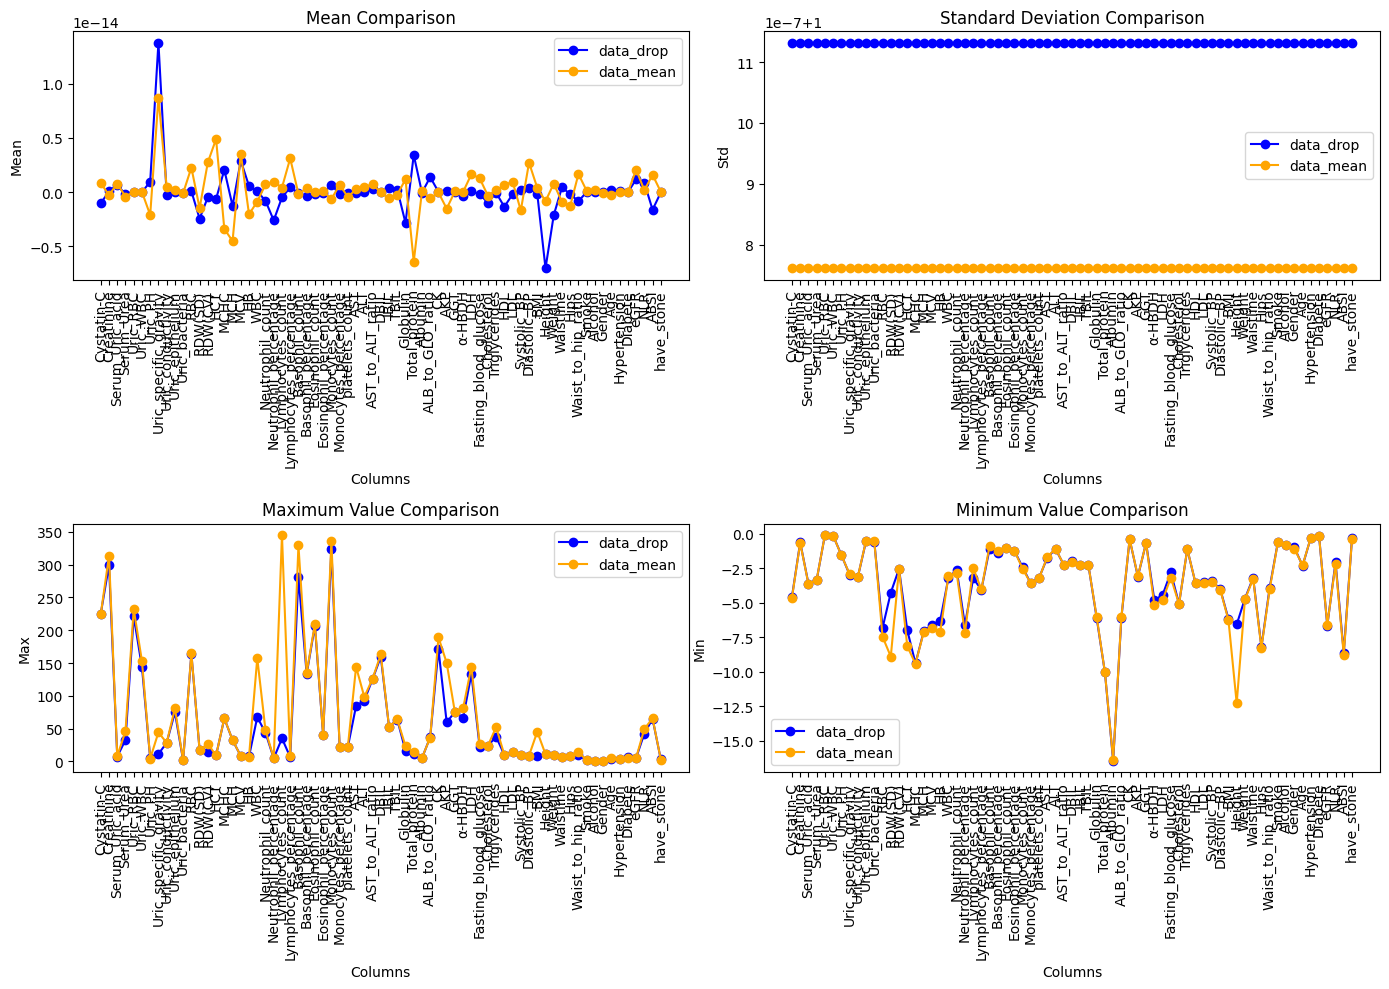

In [20]:
# 获取数值列
numeric_columns = data_drop_scaled.select_dtypes(include=[np.number]).columns
numeric_columns_mean = data_mean_scaled.select_dtypes(include=[np.number]).columns

# 初始化存储统计信息的 DataFrame
stats_drop = pd.DataFrame(index=numeric_columns, columns=['Mean', 'Std', 'Min', 'Max'])
stats_mean = pd.DataFrame(index=numeric_columns_mean, columns=['Mean', 'Std', 'Min', 'Max'])

# 计算统计信息
for col in numeric_columns:
    stats_drop.loc[col, 'Mean'] = data_drop_scaled[col].mean()
    stats_drop.loc[col, 'Std'] = data_drop_scaled[col].std()
    stats_drop.loc[col, 'Min'] = data_drop_scaled[col].min()
    stats_drop.loc[col, 'Max'] = data_drop_scaled[col].max()

    stats_mean.loc[col, 'Mean'] = data_mean_scaled[col].mean()
    stats_mean.loc[col, 'Std'] = data_mean_scaled[col].std()
    stats_mean.loc[col, 'Min'] = data_mean_scaled[col].min()
    stats_mean.loc[col, 'Max'] = data_mean_scaled[col].max()

# 绘制折线图对比
plt.figure(figsize=(14, 10))

# 均值对比
plt.subplot(2, 2, 1)
plt.plot(stats_drop.index, stats_drop['Mean'], label='data_drop', marker='o', linestyle='-', color='blue')
plt.plot(stats_mean.index, stats_mean['Mean'], label='data_mean', marker='o', linestyle='-', color='orange')
plt.title('Mean Comparison')
plt.xlabel('Columns')
plt.ylabel('Mean')
plt.xticks(rotation=90)
plt.legend()

# 标准差对比
plt.subplot(2, 2, 2)
plt.plot(stats_drop.index, stats_drop['Std'], label='data_drop', marker='o', linestyle='-', color='blue')
plt.plot(stats_mean.index, stats_mean['Std'], label='data_mean', marker='o', linestyle='-', color='orange')
plt.title('Standard Deviation Comparison')
plt.xlabel('Columns')
plt.ylabel('Std')
plt.xticks(rotation=90)
plt.legend()

# 最大值对比
plt.subplot(2, 2, 3)
plt.plot(stats_drop.index, stats_drop['Max'], label='data_drop', marker='o', linestyle='-', color='blue')
plt.plot(stats_mean.index, stats_mean['Max'], label='data_mean', marker='o', linestyle='-', color='orange')
plt.title('Maximum Value Comparison')
plt.xlabel('Columns')
plt.ylabel('Max')
plt.xticks(rotation=90)
plt.legend()

# 最小值对比
plt.subplot(2, 2, 4)
plt.plot(stats_drop.index, stats_drop['Min'], label='data_drop', marker='o', linestyle='-', color='blue')
plt.plot(stats_mean.index, stats_mean['Min'], label='data_mean', marker='o', linestyle='-', color='orange')
plt.title('Minimum Value Comparison')
plt.xlabel('Columns')
plt.ylabel('Min')
plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

In [2]:
from scipy.stats import sem, t
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, f1_score, \
    precision_score, recall_score, accuracy_score
def calculate_metrics(model, X_test, Y_test) -> list:
    # 预测概率
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(Y_test, y_pred_prob)
    accuracy = accuracy_score(Y_test, model.predict(X_test))
    sensitivity = recall_score(Y_test, model.predict(X_test))
    specificity = recall_score(Y_test, model.predict(X_test), pos_label=0)
    ppv = precision_score(Y_test, model.predict(X_test))
    npv = precision_score(Y_test, model.predict(X_test), pos_label=0)
    f1 = f1_score(Y_test, model.predict(X_test))
    # 计算95%置信区间
    auc_se = sem(y_pred_prob)
    # 计算t分布的临界值，自由度为n-2（n是样本数量）
    n = len(Y_test)
    t_critical = t.ppf((1 + 0.95) / 2, n - 2)
    # 计算AUC的95%置信区间
    auc_ci_low = auc_score - t_critical * auc_se
    auc_ci_high = auc_score + t_critical * auc_se

    return [auc_score, auc_ci_low, auc_ci_high, accuracy, sensitivity, specificity, ppv, npv, f1]

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_train, X_test, _, _ = train_test_split(data_drop.drop(['have_stone'], axis=1), data_drop['have_stone'], test_size=0.2, random_state=42)
_, _, Y_train, Y_test = train_test_split(data_mean.drop(['have_stone'], axis=1), data_mean['have_stone'], test_size=0.2, random_state=42)

model = XGBClassifier()
model.fit(X_train, Y_train)
metrics = calculate_metrics(model, X_test, Y_test)
print(metrics)
# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(Y_test, model.predict_proba(X_test)[:, 1])
# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc_score(Y_test, model.predict_proba(X_test)[:, 1])), color='blue')
plt.plot([0, 1], [0, 1], 'r--')  # 对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


XGBoostError: [16:30:23] D:\bld\xgboost-split_1738880195977\work\src\data\data.cc:508: Check failed: this->labels.Size() % this->num_row_ == 0 (171962 vs. 0) : Incorrect size for labels.

[0.6297206241318739, 0.6293011790372285, 0.6301400692265193, 0.890892201799936, 0.0036206656454532793, 0.9998290247572151, 0.7222222222222222, 0.8909847180534183, 0.007205209921019814]


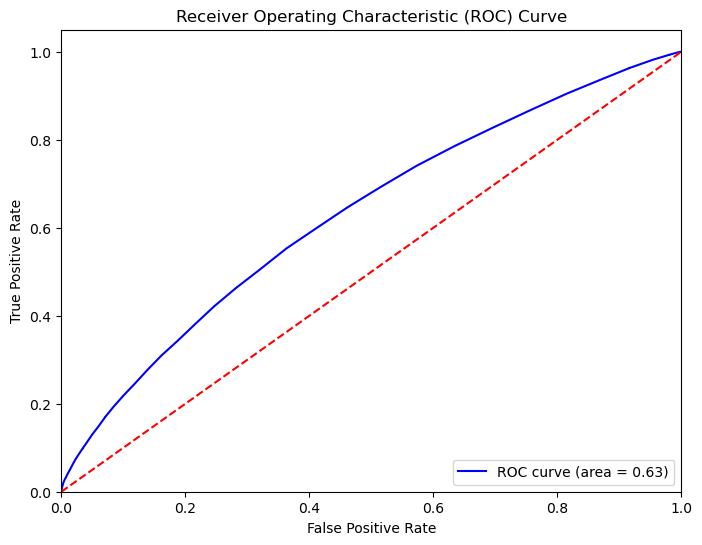

In [4]:
from sklearn.ensemble import RandomForestClassifier


model_randomForest = RandomForestClassifier()
model_randomForest.fit(X_train, Y_train)
metrics_randomForest = calculate_metrics(model_randomForest, X_test, Y_test)
print(metrics_randomForest)
# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(Y_test, model_randomForest.predict_proba(X_test)[:, 1])
# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc_score(Y_test, model_randomForest.predict_proba(X_test)[:, 1])),
         color='blue')
plt.plot([0, 1], [0, 1], 'r--')  # 对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()